## **DATA SCRAPING**

In [ ]:
pip install google-play-scraper

In [ ]:
import pandas as pd
from google_play_scraper import reviews, Sort

In [ ]:
com.mobile.legends

**DATA NEGARA INDONESIA**

In [ ]:
app_id = 'com.mobile.legends'

def get_reviews_by_date(
    app_id,
    lang='id',
    country='id',
    count=10000,
    start_date='2026-03-28',
    end_date='2026-04-15'
):

    all_reviews = []
    continuation_token = None

    start_dt = datetime.strptime(start_date, '%Y-%m-%d')
    end_dt = datetime.strptime(end_date, '%Y-%m-%d')

    while True:
        try:
            result, continuation_token = reviews(
                app_id,
                lang=lang,
                country=country,
                sort=Sort.NEWEST,
                count=count,
                continuation_token=continuation_token
            )

            if not result:
                break

            for r in result:

                review_date = r.get('at')

                if review_date is None:
                    continue

                if start_dt <= review_date <= end_dt:

                    rec = {
                        'username': r.get('userName'),
                        'rating': r.get('score'),
                        'review': r.get('content'),
                        'date': review_date
                    }

                    all_reviews.append(rec)

                elif review_date < start_dt:
                    continuation_token = None
                    break

            if continuation_token is None:
                break

        except Exception as e:
            print("Error:", e)
            break

    return all_reviews

In [ ]:
from datetime import datetime

In [ ]:
data = get_reviews_by_date(app_id)

df_id = pd.DataFrame(data)

In [ ]:
df_id['negara'] = 'Indonesia'

In [ ]:
df_id.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22135 entries, 0 to 22134
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   username  22135 non-null  object        
 1   rating    22135 non-null  int64         
 2   review    22135 non-null  object        
 3   date      22135 non-null  datetime64[ns]
 4   negara    22135 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 864.8+ KB


**DATA NEGARA FILIPINA**

In [ ]:
app_id = 'com.mobile.legends'

def get_reviews_by_date(
    app_id,
    lang='ph',
    country='ph',
    count=10000,
    start_date='2026-03-28',
    end_date='2026-05-01'
):

    all_reviews = []
    continuation_token = None

    start_dt = datetime.strptime(start_date, '%Y-%m-%d')
    end_dt = datetime.strptime(end_date, '%Y-%m-%d')

    while True:
        try:
            result, continuation_token = reviews(
                app_id,
                lang=lang,
                country=country,
                sort=Sort.NEWEST,
                count=count,
                continuation_token=continuation_token
            )

            if not result:
                break

            for r in result:

                review_date = r.get('at')

                if review_date is None:
                    continue

                if start_dt <= review_date <= end_dt:

                    rec = {
                        'username': r.get('userName'),
                        'rating': r.get('score'),
                        'review': r.get('content'),
                        'date': review_date
                    }

                    all_reviews.append(rec)

                elif review_date < start_dt:
                    continuation_token = None
                    break

            if continuation_token is None:
                break

        except Exception as e:
            print("Error:", e)
            break

    return all_reviews

In [ ]:
data = get_reviews_by_date(app_id)

df_ph = pd.DataFrame(data)

In [ ]:
df_ph['negara'] = 'Filipina'

In [ ]:
df_ph.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20656 entries, 0 to 20655
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   username  20656 non-null  object        
 1   rating    20656 non-null  int64         
 2   review    20656 non-null  object        
 3   date      20656 non-null  datetime64[ns]
 4   negara    20656 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 807.0+ KB


In [ ]:
df_ph = pd.DataFrame(result_ph)
df_ph['negara'] = 'Filipina'

In [ ]:
df = pd.concat([df_id, df_ph], ignore_index=True)

In [ ]:
df

,username,rating,review,date,negara
0,Pengguna Google,5,memang bagus sekali kali,2026-04-14 23:58:54,Indonesia
1,Pengguna Google,4,Game nya seru tapi banyak bocil dark system',2026-04-14 23:58:02,Indonesia
2,Pengguna Google,5,yg ini sudah bagus dan draft pick dah mulai se...,2026-04-14 23:49:31,Indonesia
3,Pengguna Google,1,"lawan di kasih tidak seimbang ,Hero kita tidak...",2026-04-14 23:48:30,Indonesia
4,Pengguna Google,4,game ini bagus tapi juga keburukan seperti dar...,2026-04-14 23:44:59,Indonesia
...,...,...,...,...,...
42786,A Google user,5,I LIKE TO MOVE IT MOVE IT,2026-03-28 00:18:05,Filipina
42787,A Google user,1,sebab sat menang sat kalah apa benda,2026-03-28 00:16:27,Filipina
42788,A Google user,1,"Tbh the game is great, but there is this issue...",2026-03-28 00:14:03,Filipina
42789,A Google user,1,it's does it working in mlbb,2026-03-28 00:09:05,Filipina


In [ ]:
df.to_csv("review_mobile_legends.csv", index=False)

## **DATA CLEANING**

In [ ]:
import pandas as pd
df=pd.read_csv("review_mobile_legends.csv")

In [ ]:
df.isnull().sum()

,0
username,0
rating,0
review,0
date,0
negara,0


In [ ]:
df = df.dropna(subset=['review'])

In [ ]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^\w\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_review'] = df['review'].apply(clean_text)

In [ ]:
df[['review','clean_review']].head()

,review,clean_review
0,memang bagus sekali kali,memang bagus sekali kali
1,Game nya seru tapi banyak bocil dark system',game nya seru tapi banyak bocil dark system
2,yg ini sudah bagus dan draft pick dah mulai se...,yg ini sudah bagus dan draft pick dah mulai se...
3,"lawan di kasih tidak seimbang ,Hero kita tidak...",lawan di kasih tidak seimbang hero kita tidak ...
4,game ini bagus tapi juga keburukan seperti dar...,game ini bagus tapi juga keburukan seperti dar...


In [ ]:
def label_sentimen(rating):

    if rating <= 3:
        return "negatif"
    else:
        return "positif"

df['sentimen_rating'] = df['rating'].apply(label_sentimen)

In [ ]:
df.head()

,username,rating,review,date,negara,clean_review,sentimen_rating
0,Pengguna Google,5,memang bagus sekali kali,2026-04-14 23:58:54,Indonesia,memang bagus sekali kali,positif
1,Pengguna Google,4,Game nya seru tapi banyak bocil dark system',2026-04-14 23:58:02,Indonesia,game nya seru tapi banyak bocil dark system,positif
2,Pengguna Google,5,yg ini sudah bagus dan draft pick dah mulai se...,2026-04-14 23:49:31,Indonesia,yg ini sudah bagus dan draft pick dah mulai se...,positif
3,Pengguna Google,1,"lawan di kasih tidak seimbang ,Hero kita tidak...",2026-04-14 23:48:30,Indonesia,lawan di kasih tidak seimbang hero kita tidak ...,negatif
4,Pengguna Google,4,game ini bagus tapi juga keburukan seperti dar...,2026-04-14 23:44:59,Indonesia,game ini bagus tapi juga keburukan seperti dar...,positif


In [ ]:
df.to_csv("clean review_mobile_legends.csv", index=False)

In [ ]:
pd.crosstab(df['negara'], df['sentimen_rating'])

sentimen_rating,negatif,positif
negara,,
Filipina,12637,8019
Indonesia,12922,9213


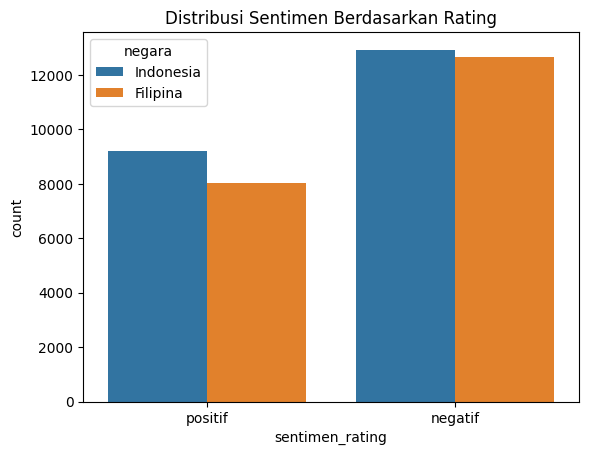

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='sentimen_rating', hue='negara')

plt.title("Distribusi Sentimen Berdasarkan Rating")
plt.show()

In [ ]:
df['negara'].value_counts()

,count
negara,
Indonesia,22135
Filipina,20656


## **DATA TRANSLATION**

In [ ]:
df = pd.concat([df_id, df_ph], ignore_index=True)

In [ ]:
df=pd.read_csv("clean review_mobile_legends.csv")

In [ ]:
pip install deep-translator tqdm

In [ ]:
import pandas as pd
from deep_translator import GoogleTranslator
from tqdm import tqdm

In [ ]:
tqdm.pandas()

In [ ]:
translator = GoogleTranslator(source='auto', target='en')

def translate_text(text):

    try:
        return translator.translate(text)

    except:
        return text

In [ ]:
df['review_translate'] = df['clean_review'].progress_apply(translate_text)

 77%|███████▋  | 33138/42791 [3:50:50<58:46,  2.74it/s]  

In [ ]:
df.to_csv("mlbb_review_translated.csv", index=False)

**INDOBERT**